In [1]:
import import_ipynb
import numpy as np
import sys
import matplotlib.pyplot as plt
from itertools import product, groupby

from grid_copy import generate_states, momentum_grid

In [2]:
mom_grid_points = momentum_grid

In [3]:
P=mom_grid_points

In [4]:
# Set parameters in the Hamiltonianin unit of f=GF/sqrt(2)/V
angle = 26.56/180.*np.pi #Sin(2*angle)=0.8
wbar = 0.0   #dm**2/(4*T*f)
tbar = 0.0   #T/f

dt = 0.01 
Nt = 300

nf=2

In [5]:
# """Set the initial state"""

initial_state = np.array([0,5,10,25,28,33])
initj=3

# initial_state = np.array([0,5,10,12,20,25,28,33])
# initj = 13

# initial_state = np.array([0,5,8,10,12,20,25,26,28,33])
# initj = 15

In [6]:
raw_states=generate_states(initial_state)

In [7]:
def generate_mom_states(in_state):
    temp_list = [*product(*[tuple(nf*item + i for i in range(nf)) for item in in_state])]
    temp_list = [sorted(list(item)) for item in temp_list if len(item) == len(set(item))]
    res_list = list(sub_list for sub_list, _ in groupby(sorted(temp_list)))
    return res_list

In [8]:
my_mom_states = []
for item in raw_states:
    for sub_item in generate_mom_states(item):
        my_mom_states.append(sub_item)

In [9]:
states = my_mom_states

In [10]:
# prefix = 'pub/arXiv2404_16690/'

# # infile = prefix + 'Nn6'        # Input filename  
# # initj = 3   # n=6 nitial state

# infile = prefix + 'Nn8'      # Input filename  
# initj = 13   # n=8 nitial state

# #infile = prefix + 'Nn10'      # Input filename  
# #initj = 15   # n=8 nitial state

# dt = 0.01               # Time step size
# Nt = 300#1000              # Total time steps

In [11]:
# # load momentum points from grid
# mom_grid_points = []
# with open(infile+'_p.dat', 'r') as f:
#     for lines in f.readlines():
#         l = [x for x in lines.split(' ')]
#         if l[0] == '#':
#             pass
#         else:
#             lf = [np.float64(x) for x in lines.split(' ')]
#             mom_grid_points.append(lf)

# mom_grid_points = np.array(mom_grid_points)
K = len(mom_grid_points)
Nb = 2 * K
# print(f'Number of momentum modes: {K}')

In [12]:
# # List states

# states = []

# with open(infile+'_s.dat', 'r') as f:
#     for lines in f.readlines():
#         l = [int(x) for x in lines.split(' ')]
#         nstate = int(2**len(l)/4**(len(l)-len(list(set(l)))))
#         rp = []
#         if nstate < 2**len(l):
#             for i in range(len(l)-1):
#                 if l[i]==l[i+1]:
#                     rp.append(l[i])
#         nrp = [x for x in l if x not in rp]
#         numnrp = len(nrp)
#         for i in range(nstate):
#             state = []
#             for j in range(len(rp)):
#                 state.append(2*rp[j])
#                 state.append(2*rp[j]+1)
#             for j in range(numnrp):
#                 state.append(2*nrp[j]+(i//2**(numnrp-j-1))%2)
#             states.append(sorted(state))

In [13]:
# """ I added this """
# num_l = 0
# num_repeat = 0
# repeats = []
# with open(infile+'_s.dat', 'r') as f:
#     for lines in f.readlines():
#         num_l += 1
#         l = [int(x) for x in lines.split(' ')]
#         if len(l) != len(set(l)):
#             num_repeat += 1
#             repeats.append(l)

In [14]:
l = my_mom_states[0]

In [15]:
Nn = len(l)
bstr_to_j = {}
j_to_bstr = {}
Ns = len(states)
for i in range(Ns):
    b = ','.join(str(int(x)) for x in states[i])
    bstr_to_j[b] = i 
    j_to_bstr[i] = b


print(f'The number of basis states: {Ns}')
print(f'The number of neutrinos: {Nn}')

The number of basis states: 672
The number of neutrinos: 6


In [16]:
Nb

70

In [17]:
# Input is a state's binary representation, return its basis index j
def b_to_j(b):
    oc = []
    for i in range(Nb):
        if b[i]==1:
            oc.append(i)
    bstr = ','.join(str(x) for x in oc)
    return bstr_to_j[bstr]

# Input is the basis index j, and returns its binary representation
def j_to_b(j):
    bstr = j_to_bstr[j]
    oc = [int(x) for x in bstr.split(',')]
    b = [0]*Nb
    for i in range(len(oc)):
        b[oc[i]] = 1
    return b

In [18]:
b_to_j(j_to_b(35))

35

In [19]:
# Given neutrino's mode index and flavor, return its bin number k = K*flavor + p
def bin(p, flavor):
    return 2*p + flavor

# given bin index (0 - Nb-1), returns momenta(index) and flavor
def pf(i):
    return i//2, i%2

In [20]:
# Applying a*(b1)a(b2) to a basis state, b = [b1,b2]
def quad(b, basis):
    basis_copy = basis.copy()
    l = 1
    f = 1.0
    if basis_copy[b[1]] == 0:
        l = 0
    else:
        basis_copy[b[1]] = 0
        f = f * (-1)**np.sum(basis_copy[:b[1]])
    if basis_copy[b[0]] ==1:
        l = 0
    else:
        basis_copy[b[0]] = 1
        f = f * (-1)**np.sum(basis_copy[:b[0]])
    return l, f, basis_copy

In [101]:
b_to_j(quad([1, 1], j_to_b(1))[-1])

KeyError: '0,1,10,20,50,56,67'

In [109]:
quar([0, 0, 0, 37], j_to_b(0))

(0,
 np.float64(1.0),
 [1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0])

In [22]:
# Applying a*(b1)a*(b2)a(b3)a(b4) to state, b = [b1,b2,b3,b4]
def quar(b, basis):
    basis_copy = basis.copy()
    l = 1
    f = 1.0
    if basis_copy[b[3]] == 0:
        l = 0
    else:
        basis_copy[b[3]] = 0
        f = f * (-1)**np.sum(basis_copy[:b[3]])
    if basis_copy[b[2]] == 0:
        l = 0
    else:
        basis_copy[b[2]] = 0
        f = f * (-1)**np.sum(basis_copy[:b[2]])
    if basis_copy[b[1]] ==1:
        l = 0
    else:
        basis_copy[b[1]] = 1
        f = f * (-1)**np.sum(basis_copy[:b[1]])
    if basis_copy[b[0]] ==1:
        l = 0
    else:
        basis_copy[b[0]] = 1
        f = f * (-1)**np.sum(basis_copy[:b[0]])

    return l, f, basis_copy

In [23]:
# mass term applied to basis state j.
def mass(j):
    sin = j_to_b(j)
    state = np.zeros(Ns) * 1j
    for p in range(K):
        ke = bin(p, 0)
        km = bin(p, 1)
        absp = np.sqrt(np.sum(P[p]*P[p]))
        factor_ee = tbar*absp - np.cos(2*angle)*wbar/absp
        factor_mm = tbar*absp + np.cos(2*angle)*wbar/absp
        factor_em = np.sin(2*angle)*wbar/absp
        factor_me = factor_em
        t, fa, sout = quad([ke, ke], sin)
        # e -> e
        if t == 1:
            state[b_to_j(sout)] += fa * factor_ee 
        t, fa, sout = quad([km, km], sin) 
        # mu -> mu
        if t == 1:
            state[b_to_j(sout)] += fa * factor_mm 
        # mu -> e 
        t, fa, sout = quad([ke, km], sin) 
        if t == 1:
            state[b_to_j(sout)] += fa * factor_em 
        # e -> mu
        t, fa, sout = quad([km, ke], sin) 
        if t == 1:
            state[b_to_j(sout)] += fa * factor_me 

    return state

In [24]:
flavor_pair = np.array([[0,0],[0,1],[1,0],[1,1]]) # flavor (alpha, beta)

In [25]:
# Input is 3-dim momentum, returns |p|, theta and phi (0-2pi)
def p_spherical(p):
    absp = np.sqrt(np.sum(p*p))
    theta = np.arctan2(np.sqrt(p[0]**2+p[1]**2), p[2])
    phi = np.arctan2(p[1],p[0])
    return absp, theta, phi

# g factor for H_vv
def g_factor(p1, p2, q1, q2):
    absp1, tp1, pp1 = p_spherical(p1)
    absp2, tp2, pp2 = p_spherical(p2)
    absq1, tq1, pq1 = p_spherical(q1)
    absq2, tq2, pq2 = p_spherical(q2)
    fac1 = np.exp(-1j*pq1)*np.sin(tq1/2.)*np.cos(tq2/2.) - np.exp(-1j*pq2)*np.cos(tq1/2.)*np.sin(tq2/2.)
    fac2 = np.exp(1j*pp1)*np.sin(tp1/2.)*np.cos(tp2/2.) - np.exp(1j*pp2)*np.cos(tp1/2.)*np.sin(tp2/2.)
    return 2 * fac1 * fac2

# def g_factor(p1, p2, q1, q2):
#     absp1, tp1, pp1 = p_spherical(p1)
#     absp2, tp2, pp2 = p_spherical(p2)
#     absq1, tq1, pq1 = p_spherical(q1)
#     absq2, tq2, pq2 = p_spherical(q2)
#     fac1 = np.exp(-1j*pq1)*np.sin(tq1/2.)*np.cos(tq2/2.) - np.exp(-1j*pq2)*np.cos(tq1/2.)*np.sin(tq2/2.)
#     fac2 = np.exp(1j*pp1)*np.sin(tp1/2.)*np.cos(tp2/2.) - np.exp(1j*pp2)*np.cos(tp1/2.)*np.sin(tp2/2.)
#     if ((p1==q1).all() and (p2==q2).all()) or ((p1==q2).all() and (p2==q1).all()):
#         res = 2 * fac1 * fac2
#     else:
#         res = 0
#     return res

In [88]:
P

array([[ 1, -4,  0],
       [ 2, -4,  0],
       [ 3, -4,  0],
       [ 1, -3,  0],
       [ 2, -3,  0],
       [ 3, -3,  0],
       [ 4, -3,  0],
       [ 1, -2,  0],
       [ 2, -2,  0],
       [ 3, -2,  0],
       [ 4, -2,  0],
       [ 1, -1,  0],
       [ 2, -1,  0],
       [ 3, -1,  0],
       [ 4, -1,  0],
       [ 1,  0,  0],
       [ 2,  0,  0],
       [ 3,  0,  0],
       [ 4,  0,  0],
       [ 5,  0,  0],
       [ 1,  1,  0],
       [ 2,  1,  0],
       [ 3,  1,  0],
       [ 4,  1,  0],
       [ 1,  2,  0],
       [ 2,  2,  0],
       [ 3,  2,  0],
       [ 4,  2,  0],
       [ 1,  3,  0],
       [ 2,  3,  0],
       [ 3,  3,  0],
       [ 4,  3,  0],
       [ 1,  4,  0],
       [ 2,  4,  0],
       [ 3,  4,  0]])

In [89]:
print(f'Creating the list of conserved 4 momenta')
momenta4 = []
gfactors = []
for i1 in range(K):
    p1 = P[i1]
    for i2 in range(K):
        p2 = P[i2]
        for i3 in range(K):
            p3 = P[i3]
            for i4 in range(K):
                p4 = P[i4]
                pdiff = p1+p2-p3-p4
                if np.sum(np.abs(pdiff)) < 1e-7:
                    k1 = np.sqrt(np.sum(p1*p1))
                    k2 = np.sqrt(np.sum(p2*p2))
                    k3 = np.sqrt(np.sum(p3*p3))
                    k4 = np.sqrt(np.sum(p4*p4))
                    gfactor = g_factor(p1,p2,p3,p4)
                    if np.abs(k1+k2-k3-k4) < 1e-7 and np.abs(gfactor) > 1e-7:
                        momenta4.append([i1, i2, i3, i4])
                        gfactors.append(gfactor)
# 

momenta4 = np.array(momenta4)
gfactors = np.array(gfactors)
print(f'Number of conserved P and conserved E pairs: {len(momenta4)}')  

# full 4 fermi interaction term applied to basis state j.
# a*(p1,fp1)a*(p2,fp2)a(q1,fq1)a(q2,fq2) with p1+p2 = q1+q2
def vv_full(j):
    sin = j_to_b(j)
    state = np.zeros(Ns) * 1j
    for i in range(len(momenta4)):
        p1 = momenta4[i,0]
        p2 = momenta4[i,1]
        q1 = momenta4[i,2]
        q2 = momenta4[i,3] 
        factor = - gfactors[i]
        for f in range(4):
            i1 = bin(p1, flavor_pair[f,0])
            i2 = bin(p2, flavor_pair[f,1])
            i3 = bin(q1, flavor_pair[f,0])
            i4 = bin(q2, flavor_pair[f,1])
            t, fa, sout = quar([i1, i2, i3, i4], sin)
            if t == 1:
                state[b_to_j(sout)] += fa * factor
    return state

Creating the list of conserved 4 momenta
Number of conserved P and conserved E pairs: 2564


In [94]:
len(j_to_b(0))

70

In [92]:
momenta4

array([[ 0,  1,  0,  1],
       [ 0,  1,  1,  0],
       [ 0,  2,  0,  2],
       ...,
       [34, 32, 34, 32],
       [34, 33, 33, 34],
       [34, 33, 34, 33]])

In [27]:
Ns = len(my_mom_states)

In [28]:
Ns

672

In [29]:
Nb = 2*K

In [81]:
H = np.zeros((Ns, Ns))*1j

for i in range(Ns):
    column = np.zeros(Ns)*1j
    H[:,i] += mass(i)
    # H[:,i] += vv_full(i)
    if i%100==0:
        print(f'constructing {i}th column of the Hamiltonian')
              
# Diaginalize H and construct time evolution operator U
# Full Hamiltonian
hvals, hvecs = np.linalg.eigh(H) 
U = hvecs @ np.diag(np.exp(-dt*hvals*1j)) @ hvecs.conj().T

constructing 0th column of the Hamiltonian
constructing 100th column of the Hamiltonian
constructing 200th column of the Hamiltonian
constructing 300th column of the Hamiltonian
constructing 400th column of the Hamiltonian
constructing 500th column of the Hamiltonian
constructing 600th column of the Hamiltonian


In [82]:
i, j = 0, 0
for item in H:
    for sub_item in item:
        j+=1
        if sub_item != 0:
            i+=1

In [86]:
j

451584

In [74]:
k=0
for item in vv_full(7):
    if item!=0:
        k+=1
k

16

In [67]:
k

4

In [45]:
my_thing = np.zeros((5,5))*1j
for i in range(5):
    my_thing[:, i] += mass(i)
    my_thing[:, i] += vv_full(i)

ValueError: operands could not be broadcast together with shapes (5,) (672,) (5,) 

In [54]:
vv_full(671)

array([ 0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
        0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
        0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
        0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
        0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
        0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
        0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
        0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
        0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
        0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
        0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
        0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
        0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
        0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
        0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
        0.        +0.0000

In [27]:
# norm and observables of interest
def norm(state):
    return np.sqrt(np.sum(state * state.conj()))

# input is the state vector, returns the # of neutrino in each bin (Nb)
def observable(state):
    obs = np.zeros(Nb)
    for i in range(Ns):
        binary = j_to_b(i)
        obs += np.abs(state[i])**2*np.array(binary)
    return obs

# returns string of time and wave function amplitude
def print_cstr(state,i):
    return str(i*dt) + ' ' + ' '.join([str(x) for x in state]) 

# returns string of time and occupation number per bin
def print_nstr(state,i):
    obs = observable(state)
    return str(i*dt) + ' ' + ' '.join([str(x) for x in obs]) 


# Time evolution from the initial state j    
state = np.zeros(Ns)*1j
state[initj] = 1.0

In [28]:
init_state = state

In [74]:
state = np.zeros(Ns)*1j
state[initj] = 1.0

init_state = state

times = []
echo_6 = []
# echo_8 = []
# echo_6_trunc = []
# echo_8_trunc = []

times.append(0)
echo_6.append(np.abs(state @ init_state)**2)
# echo_8.append(np.abs(state @ init_state)**2)
# echo_6_trunc.append(np.abs(state @ init_state)**2)
# echo_8_trunc.append(np.abs(state @ init_state)**2)

for i in range(1, Nt+1):
    state = U @ state
    n = norm(state)
    if abs(n-1.) > 1e-5:
        print('Norm off by > 1e-5 at time ', i*dt)
        break
    print('-'*30)
    print(np.abs(state @ init_state)**2)
    times.append(i*dt)
    echo_6.append(np.abs(state @ init_state)**2)
    # echo_8.append(np.abs(state @ init_state)**2)
    # echo_6_trunc.append(np.abs(state @ init_state)**2)
    # echo_8_trunc.append(np.abs(state @ init_state)**2)

------------------------------
0.9900982746056781
------------------------------
0.9610193857392931
------------------------------
0.9145792565623794
------------------------------
0.8536027927269345
------------------------------
0.7816487601832629
------------------------------
0.7026750041520333
------------------------------
0.6206851853376554
------------------------------
0.5393985675791182
------------------------------
0.4619789178529768
------------------------------
0.3908483775041268
------------------------------
0.32759904025692393
------------------------------
0.2730011035061554
------------------------------
0.22709400190190046
------------------------------
0.18933766223588425
------------------------------
0.1587960559805964
------------------------------
0.13432489352418756
------------------------------
0.11473913882647033
------------------------------
0.09894292479802576
------------------------------
0.08601293212993236
------------------------------
0.0752347829

In [3]:
times = np.load('times.npy')
echo_6 = np.load('echo_6.npy')
echo_8 = np.load('echo_8.npy')
echo_6_trunc = np.load('echo_6_trunc.npy')
echo_8_trunc = np.load('echo_8_trunc.npy')

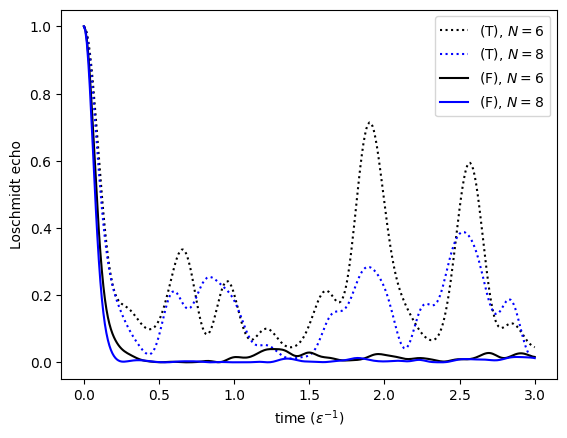

In [4]:
plt.plot(times, echo_6_trunc, color = 'black', label='(T), $N=6$', linestyle='dotted')
plt.plot(times, echo_8_trunc, color = 'blue', label='(T), $N=8$', linestyle='dotted')
plt.plot(times, echo_6, color = 'black', label='(F), $N=6$')
plt.plot(times, echo_8, color = 'blue', label='(F), $N=8$')
plt.xlabel('time ($\\epsilon^{-1}$)')
plt.ylabel('Loschmidt echo')
plt.legend()
plt.savefig('fig_7.pdf')
plt.show()